In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent  # notebook/ 的 parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from dlphys.analysis.dmft.solver import DMFTConfig, DMFTSolver
from dlphys.analysis.dmft.init_C import INIT_REGISTRY, validate_basic
from dlphys.analysis.dmft.observables import (
    residual_memory, corr_length_exp, power_law_alpha, focus_sharpness,
    # 如果你想用 attention entropy（你现在 observables.py 里也有）
    estimate_attention_entropy_from_S,
)

In [5]:
def fit_r2_exp(C, lmin=1, lmax=None):
    if lmax is None:
        lmax = len(C) - 1
    lags = np.arange(lmin, lmax + 1)
    vals = C[lmin:lmax + 1]
    mask = vals > 1e-14
    if np.sum(mask) < 3:
        return np.nan
    x = lags[mask].astype(float)
    y = np.log(vals[mask].astype(float))
    p = np.polyfit(x, y, 1)
    yhat = np.polyval(p, x)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2) + 1e-30
    return 1 - ss_res / ss_tot

def fit_r2_power(C, lmin=1, lmax=None):
    if lmax is None:
        lmax = len(C) - 1
    lags = np.arange(lmin, lmax + 1)
    vals = C[lmin:lmax + 1]
    mask = (vals > 1e-14) & (lags > 0)
    if np.sum(mask) < 3:
        return np.nan
    x = np.log(lags[mask].astype(float))
    y = np.log(vals[mask].astype(float))
    p = np.polyfit(x, y, 1)
    yhat = np.polyval(p, x)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2) + 1e-30
    return 1 - ss_res / ss_tot

def solve_one_L(L: int):
    # 1) build config & solver
    cfg = DMFTConfig(
        L=L, gamma=gamma,
        n_mc=n_mc, mc_seed=mc_seed, mc_batch=mc_batch,
        damping=damping, tol=tol, max_iter=max_iter,
    )
    solver = DMFTSolver(cfg)

    # 2) init C0 from registry
    init_fn = INIT_REGISTRY[init_name]
    C0 = init_fn(L, **init_kwargs).astype(np.float64)

    # 可选：做一下基本合法性诊断（不是充分条件，但能抓出很离谱的初始化）
    diag = validate_basic(C0)

    # 3) iterate to fixed point
    out = solver.iterate(C0, verbose=False)
    Cstar = out["C_star"]
    converged = out["converged"]

    # 4) read aux objects
    aux = out["aux"] or {}
    S = aux.get("S", None)
    M = aux.get("M", None)

    # 5) observables
    q = residual_memory(Cstar)
    xi = corr_length_exp(Cstar)
    alpha = power_law_alpha(Cstar)

    # focus sharpness uses M; if not available, compute from Cstar again (costs MC)
    if M is None:
        S2 = solver.compute_S(Cstar)
        M = solver.compute_M(S2)
        S = S2

    kappa = focus_sharpness(M)

    # optional: attention entropy from S (also MC)
    H = estimate_attention_entropy_from_S(S, n_mc=50000, seed=mc_seed, batch=mc_batch)

    # fit quality
    r2e = fit_r2_exp(Cstar)
    r2p = fit_r2_power(Cstar)
    decay_choice = "exp" if (np.nan_to_num(r2e, -np.inf) >= np.nan_to_num(r2p, -np.inf)) else "power"

    return dict(
        L=L,
        converged=converged,
        C0=C0,
        Cstar=Cstar,
        err_hist=out["err_hist"],
        diag=diag,
        q=q, xi=xi, alpha=alpha,
        r2_exp=r2e, r2_power=r2p, decay_choice=decay_choice,
        kappa=kappa,
        entropy=H,
    )

In [9]:
# -----------------------------
# Experiment knobs
# -----------------------------
gamma = 0.5            # 注意：你当前实现里 gamma 暂时不会影响 compute_S 的输出
L_list = list(range(4, 65, 4))  # 扫 L：4,8,...,64

# Monte Carlo settings (M(C) 估计用)
n_mc = 50000
mc_seed = 0
mc_batch = 2000

# DMFT fixed point iteration settings
damping = 0.3
tol = 1e-7
max_iter = 300

# -----------------------------
# Choose an initialization ansatz
# -----------------------------
# 可选： "exp", "plateau_exp", "damped_cos", "power_law", "gaussian", "spectrum"
init_name = "exp"
init_kwargs = dict(xi=3.0, C0=1.0)      # 对应 init_exp(L, xi=?, C0=?)

# 举例：如果你要 plateau (q>0) basin：
# init_name = "plateau_exp"
# init_kwargs = dict(q=0.2, xi=5.0, C0=1.0)

# 举例：如果你要 power law:
# init_name = "power_law"
# init_kwargs = dict(alpha=1.0, ell0=1.0, C0=1.0)

# 举例：随机但更“物理”（谱密度非负，生成 Toeplitz 正定相关）：
# init_name = "spectrum"
# init_kwargs = dict(n_freq=256, seed=0, smooth=2.0, C0=1.0)

In [11]:
results = []
for L in L_list:
    res = solve_one_L(L)
    results.append(res)
    print(
        f"L={L:3d}  conv={res['converged']}  "
        f"q={res['q']:+.3e}  xi={res['xi']:.3g}  alpha={res['alpha']:.3g}  "
        f"kappa={res['kappa']:.3g}  H={res['entropy']:.3g}  "
        f"decay={res['decay_choice']} (R2e={res['r2_exp']:.3g}, R2p={res['r2_power']:.3g})"
    )

Ls = np.array([r["L"] for r in results], dtype=int)
q_arr = np.array([r["q"] for r in results], dtype=float)
xi_arr = np.array([r["xi"] for r in results], dtype=float)
alpha_arr = np.array([r["alpha"] for r in results], dtype=float)
kappa_arr = np.array([r["kappa"] for r in results], dtype=float)
H_arr = np.array([r["entropy"] for r in results], dtype=float)
conv_arr = np.array([r["converged"] for r in results], dtype=bool)

L=  4  conv=True  q=+1.097e-06  xi=4.63  alpha=0.437  kappa=1  H=1.61  decay=exp (R2e=0.963, R2p=0.856)
L=  8  conv=True  q=+9.976e-07  xi=8.8  alpha=0.354  kappa=1  H=2.2  decay=exp (R2e=0.943, R2p=0.755)
L= 12  conv=True  q=+9.806e-07  xi=13  alpha=0.32  kappa=1  H=2.56  decay=exp (R2e=0.937, R2p=0.711)
L= 16  conv=True  q=+9.349e-07  xi=17.2  alpha=0.301  kappa=1  H=2.83  decay=exp (R2e=0.933, R2p=0.685)
L= 20  conv=True  q=+9.298e-07  xi=21.3  alpha=0.289  kappa=1  H=3.04  decay=exp (R2e=0.932, R2p=0.668)
L= 24  conv=True  q=+9.322e-07  xi=25.5  alpha=0.28  kappa=1  H=3.22  decay=exp (R2e=0.93, R2p=0.655)
L= 28  conv=True  q=+9.427e-07  xi=29.7  alpha=0.273  kappa=1  H=3.37  decay=exp (R2e=0.929, R2p=0.645)
L= 32  conv=True  q=+9.236e-07  xi=33.9  alpha=0.268  kappa=1  H=3.5  decay=exp (R2e=0.929, R2p=0.637)
L= 36  conv=True  q=+9.126e-07  xi=38.1  alpha=0.263  kappa=1  H=3.61  decay=exp (R2e=0.928, R2p=0.631)
L= 40  conv=True  q=+9.449e-07  xi=42.3  alpha=0.26  kappa=1  H=3.71  de

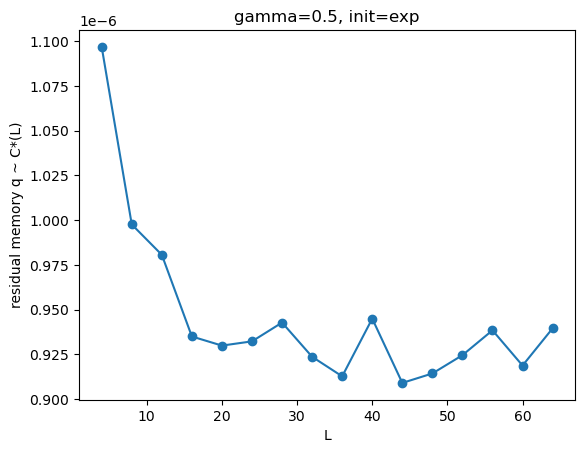

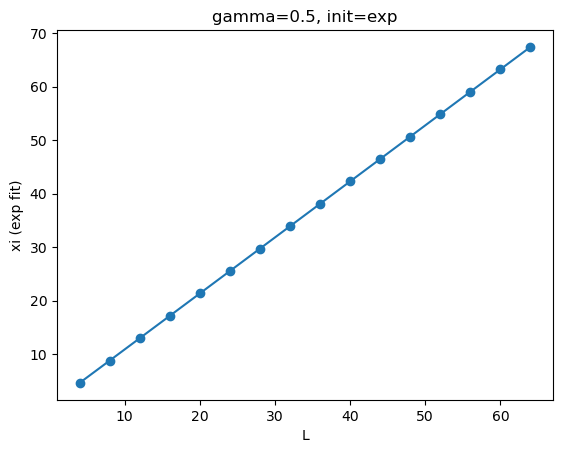

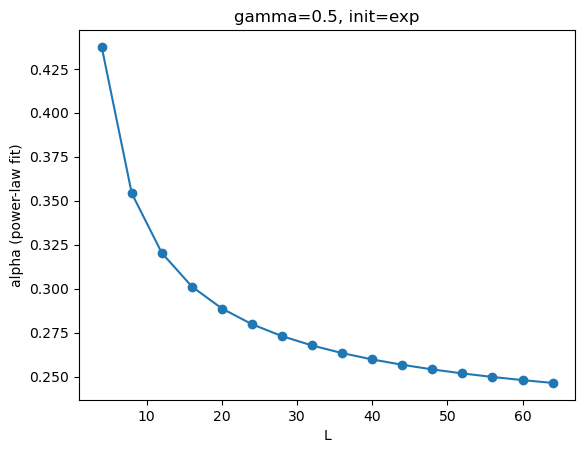

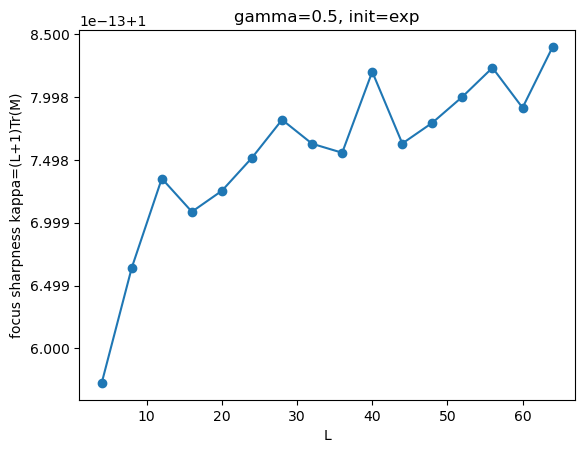

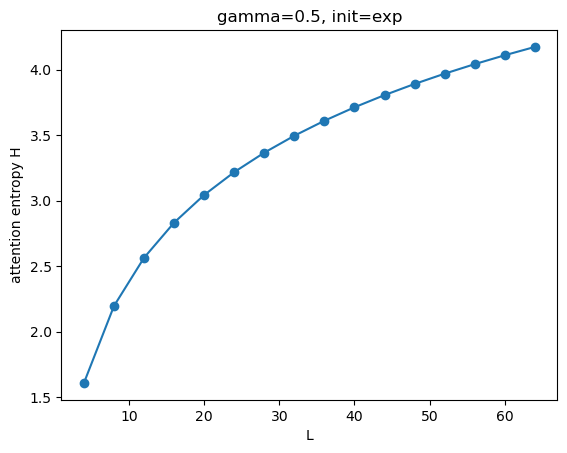

In [12]:
def _mask_conv(y):
    y2 = y.copy()
    y2[~conv_arr] = np.nan
    return y2

plt.figure()
plt.plot(Ls, _mask_conv(q_arr), marker="o")
plt.xlabel("L")
plt.ylabel("residual memory q ~ C*(L)")
plt.title(f"gamma={gamma}, init={init_name}")
plt.show()

plt.figure()
plt.plot(Ls, _mask_conv(xi_arr), marker="o")
plt.xlabel("L")
plt.ylabel("xi (exp fit)")
plt.title(f"gamma={gamma}, init={init_name}")
plt.show()

plt.figure()
plt.plot(Ls, _mask_conv(alpha_arr), marker="o")
plt.xlabel("L")
plt.ylabel("alpha (power-law fit)")
plt.title(f"gamma={gamma}, init={init_name}")
plt.show()

plt.figure()
plt.plot(Ls, _mask_conv(kappa_arr), marker="o")
plt.xlabel("L")
plt.ylabel("focus sharpness kappa=(L+1)Tr(M)")
plt.title(f"gamma={gamma}, init={init_name}")
plt.show()

plt.figure()
plt.plot(Ls, _mask_conv(H_arr), marker="o")
plt.xlabel("L")
plt.ylabel("attention entropy H")
plt.title(f"gamma={gamma}, init={init_name}")
plt.show()